In [106]:
#SCHOOL SHOOTINGS DATA ANALYSIS

# Kaggle I used: https://www.kaggle.com/datasets/sadiajavedd/students-academic-performance-dataset/data

# Stakeholders: Policymakers, school districts and administrators

In [107]:
#QUESTION TO EXPLORE: Which student background factors (gender, race, parental education, lunch type, and test 
#preparation) most strongly influence academic test performance, 
#and how can this information guide targeted interventions to improve overall student achievement?

In [108]:
#NOTEBOOK CONTENT:
#Step 1: Install + Import Necessary Libraries
#Step 2: Reading + Exploring Data
#Step 3: Data Cleaning + Preprocessing
#Step 4: Data Analysis + Visualization
#Step 5: Student Performance Data Analysis Final Results

In [109]:
#Step1: Install and Import Necessary Libraries:
!pip install kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sadiajavedd/students-academic-performance-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\dmadd\.cache\kagglehub\datasets\sadiajavedd\students-academic-performance-dataset\versions\1


In [187]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [188]:
#Step2: Reading and Exploring Data:

In [189]:
df = pd.read_csv('Downloads\StudentsPerformance.csv')

In [190]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [192]:
df.shape

(1000, 8)

In [193]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [194]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [195]:
#Step 3: Data Cleaning and Preprocessing

In [196]:
df = df.rename(columns={
    "gender": "gender",
    "race/ethnicity": "race",
    "parental level of education": "parent_edu",
    "lunch": "lunch",
    "test preparation course": "test_prep",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
})

df.head()


,gender,race,parent_edu,lunch,test_prep,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


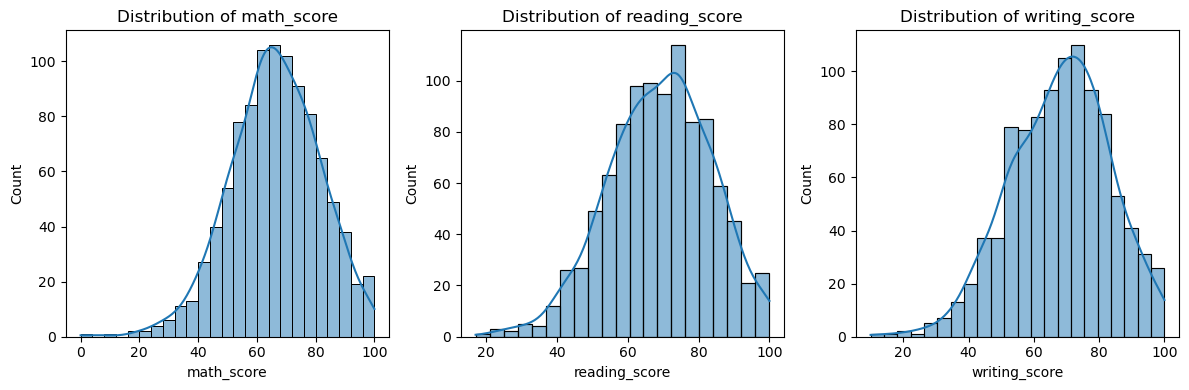

In [197]:
#Data Analysis and Visualization
#Exploratory Data Analysis (EDA)

score_cols = ["math_score", "reading_score", "writing_score"]

plt.figure(figsize=(12, 4))
for i, col in enumerate(score_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


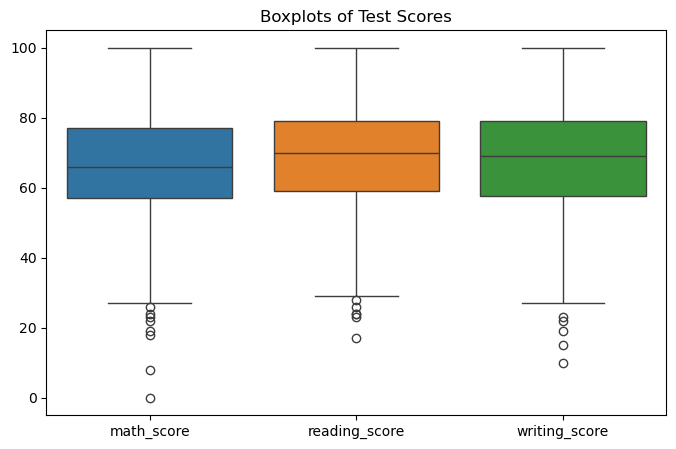

In [198]:
#Boxplot of Scores
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[score_cols])
plt.title("Boxplots of Test Scores")
plt.show()


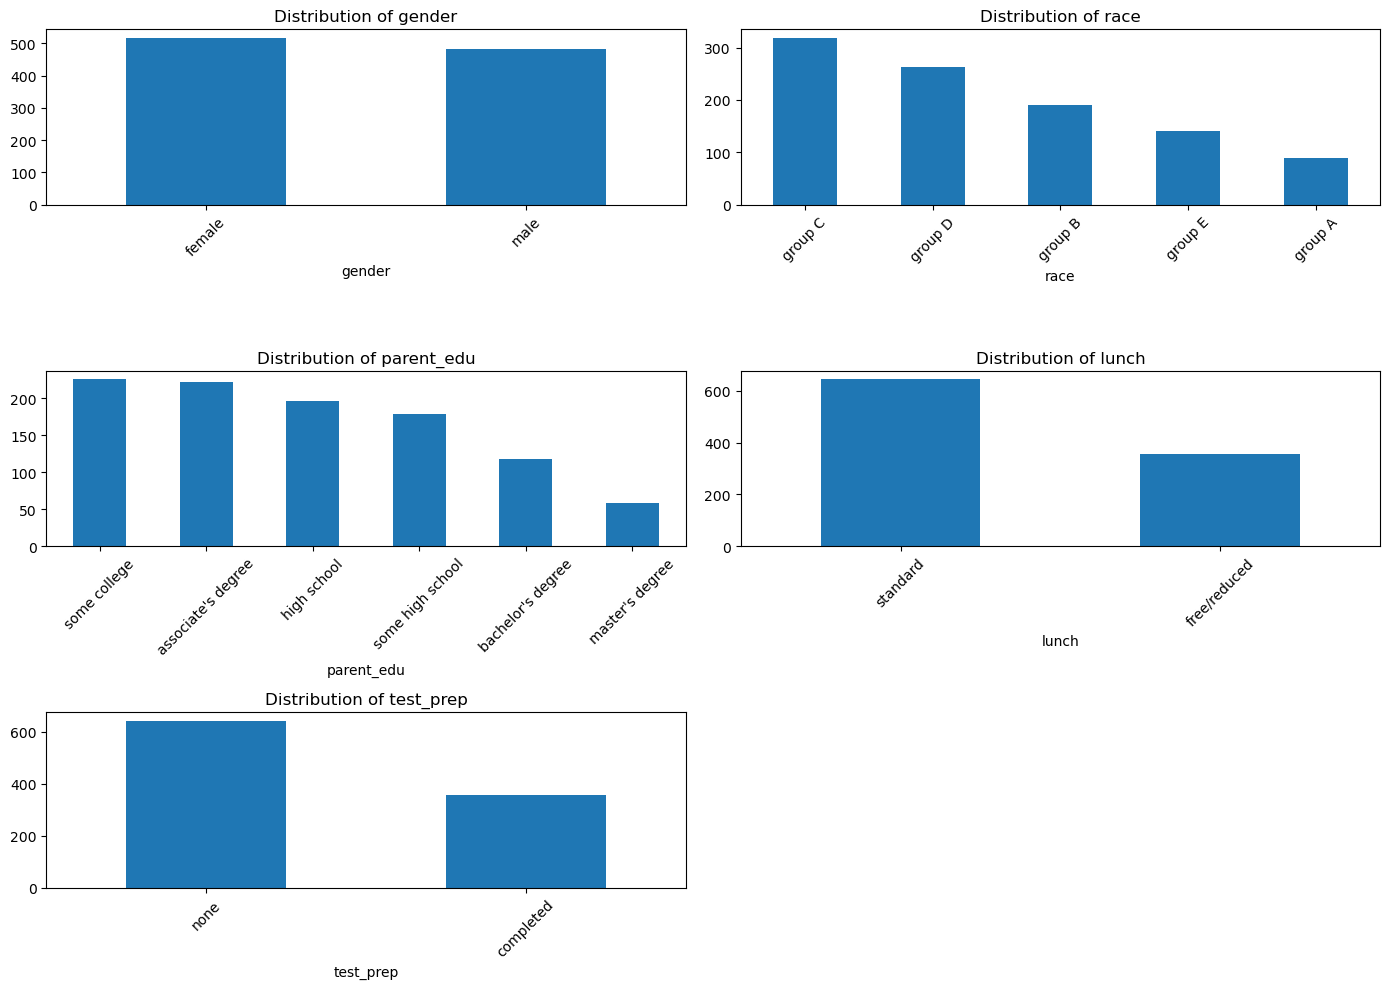

In [199]:
#Categorical Feature Distributions
cat_cols = ["gender", "race", "parent_edu", "lunch", "test_prep"]

plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

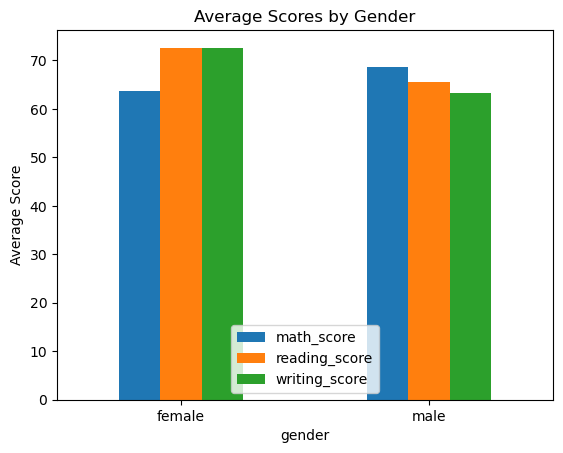

In [200]:
#Group Comparisons by Gender
df.groupby("gender")[score_cols].mean()

plt.figure(figsize=(8, 5))
df.groupby("gender")[score_cols].mean().plot(kind="bar")
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()


<Figure size 1000x500 with 0 Axes>

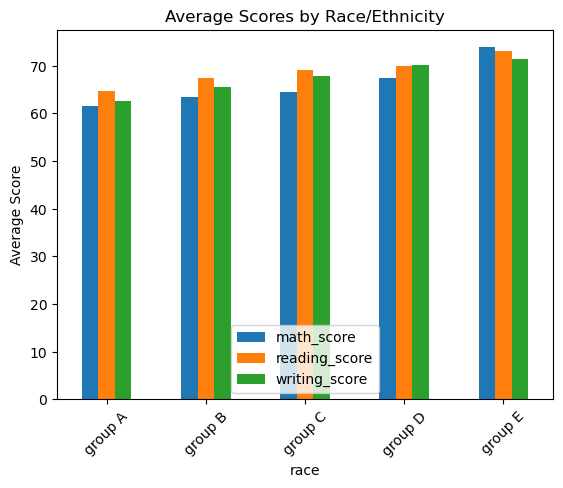

In [201]:
#Group Comparisons by Race
df.groupby("race")[score_cols].mean()

plt.figure(figsize=(10, 5))
df.groupby("race")[score_cols].mean().plot(kind="bar")
plt.title("Average Scores by Race/Ethnicity")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()


<Figure size 1000x500 with 0 Axes>

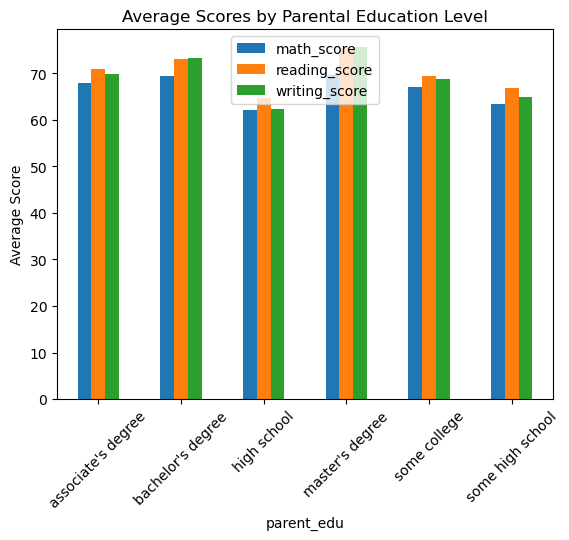

In [202]:
#Group Comparison by Parent Education
df.groupby("parent_edu")[score_cols].mean().sort_values("math_score", ascending=False)

plt.figure(figsize=(10, 5))
df.groupby("parent_edu")[score_cols].mean().plot(kind="bar")
plt.title("Average Scores by Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()




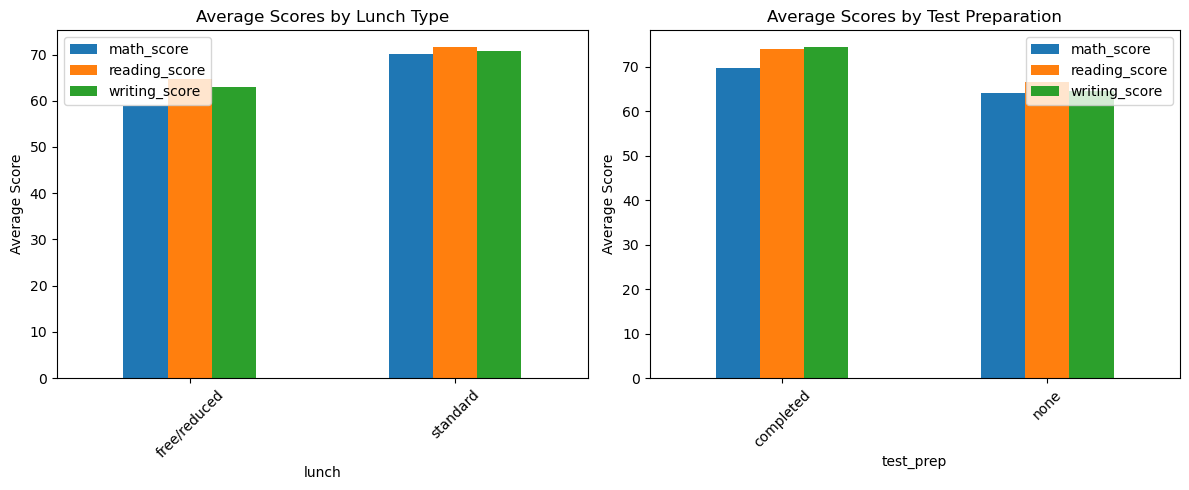

In [203]:
#Group Comparison by Lunch Type and Test Prep

df.groupby("lunch")[score_cols].mean()

df.groupby("test_prep")[score_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby("lunch")[score_cols].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Scores by Lunch Type")
axes[0].set_ylabel("Average Score")
axes[0].tick_params(axis='x', rotation=45)

df.groupby("test_prep")[score_cols].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Scores by Test Preparation")
axes[1].set_ylabel("Average Score")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [204]:
#Linear Regression Coefficients
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred_lin)
mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Linear Regression - Math Score")
print(f"R2:   {r2:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


Linear Regression - Math Score
R2:   0.176
MAE:  11.270
RMSE: 14.160


In [205]:
# Example: independent t-test for math scores by gender
male_math = df[df["gender"] == "male"]["math_score"]
female_math = df[df["gender"] == "female"]["math_score"]

t_stat, p_val = stats.ttest_ind(male_math, female_math, equal_var=False)
print("Math Score by Gender - t-test")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.5f}")


Math Score by Gender - t-test
t-statistic: 5.398, p-value: 0.00000


In [206]:
groups = [group["math_score"].values for name, group in df.groupby("race")]
f_stat, p_val = stats.f_oneway(*groups)

print("Math Score by Race/Ethnicity - One-way ANOVA")
print(f"F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")


Math Score by Race/Ethnicity - One-way ANOVA
F-statistic: 14.594, p-value: 0.00000


In [207]:
std_lunch_math = df[df["lunch"] == "standard"]["math_score"]
free_lunch_math = df[df["lunch"] != "standard"]["math_score"]

t_stat, p_val = stats.ttest_ind(std_lunch_math, free_lunch_math, equal_var=False)
print("Math Score by Lunch Type - t-test")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.5f}")


Math Score by Lunch Type - t-test
t-statistic: 11.484, p-value: 0.00000


In [208]:
completed_math = df[df["test_prep"] == "completed"]["math_score"]
none_math = df[df["test_prep"] != "completed"]["math_score"]

t_stat, p_val = stats.ttest_ind(completed_math, none_math, equal_var=False)
print("Math Score by Test Prep - t-test")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.5f}")


Math Score by Test Prep - t-test
t-statistic: 5.787, p-value: 0.00000


In [209]:
#SECTION 4: Modeling

In [210]:
# Copy to avoid messing original if you want
model_df = df.copy()

# One-hot encode categorical variables
X = pd.get_dummies(model_df[["gender", "race", "parent_edu", "lunch", "test_prep"]], drop_first=True)

# Target: choose one (e.g., math_score)
y_math = model_df["math_score"]

X.head()

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [211]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_math, test_size=0.2, random_state=42
)
#Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred_lin)
mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Linear Regression - Math Score")
print(f"R2:   {r2:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


Linear Regression - Math Score
R2:   0.176
MAE:  11.270
RMSE: 14.160


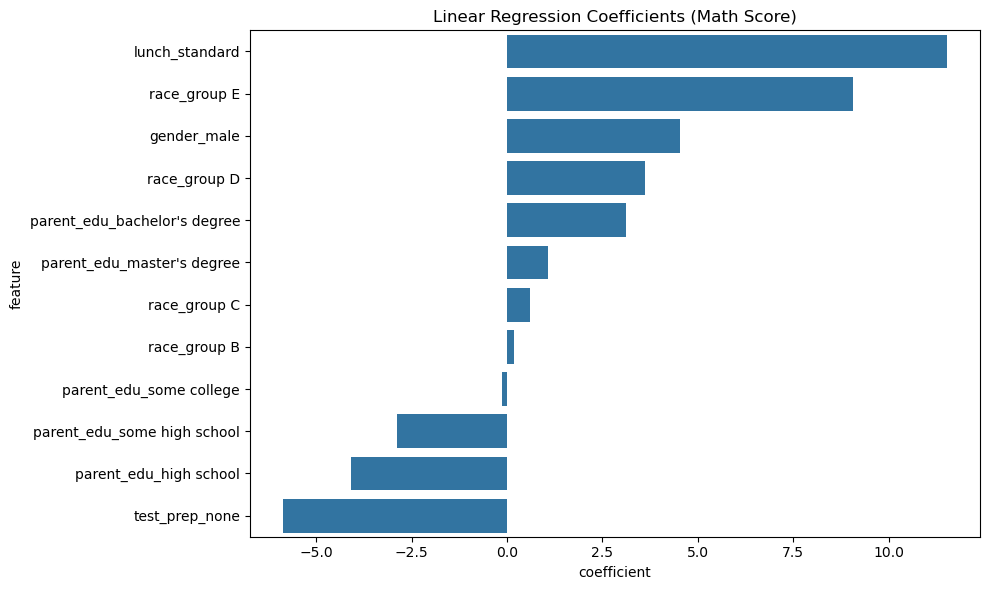

In [212]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", ascending=False)

coef_df

plt.figure(figsize=(10, 6))
sns.barplot(x="coefficient", y="feature", data=coef_df)
plt.title("Linear Regression Coefficients (Math Score)")
plt.tight_layout()
plt.show()



In [213]:
#Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=200, random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest - Math Score")
print(f"R2:   {r2_rf:.3f}")
print(f"MAE:  {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")


Random Forest - Math Score
R2:   -0.026
MAE:  12.459
RMSE: 15.801


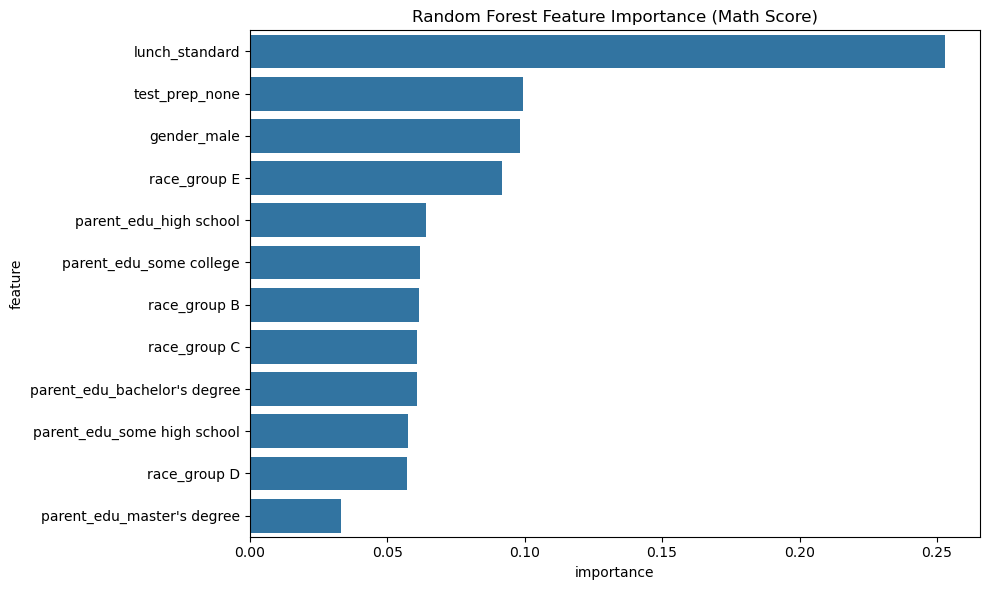

In [214]:
#Feature Importance

importances = rf.feature_importances_
feat_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_importances

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feat_importances)
plt.title("Random Forest Feature Importance (Math Score)")
plt.tight_layout()
plt.show()


In [215]:
def model_score(target_col):
    y = model_df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    lin = LinearRegression()
    lin.fit(X_train, y_train)
    y_pred = lin.predict(X_test)

    print(f"=== Linear Regression for {target_col} ===")
    print(f"R2: {r2_score(y_test, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
    print()

for col in ["math_score", "reading_score", "writing_score"]:
    model_score(col)


=== Linear Regression for math_score ===
R2: 0.176
MAE: 11.270
RMSE: 14.160

=== Linear Regression for reading_score ===
R2: 0.159
MAE: 10.830
RMSE: 13.792

=== Linear Regression for writing_score ===
R2: 0.264
MAE: 10.193
RMSE: 13.321



In [216]:
## Conclusions & Insights

#- **Key factors:** Summarize which variables (gender, race, parent_edu, lunch, test_prep) show the strongest relationships with scores.
#- **Direction of effect:** Note which groups tend to have higher/lower scores.
#- **Model performance:** Comment on R², MAE, and if the models are good enough for decision support.
#- **Implications:** Briefly mention how schools might use these findings (e.g., expand test prep, support specific groups, etc.).
#- **Limitations:** Acknowledge that this is cross-sectional data from one dataset, not a full causal study.


In [217]:
# First, define the preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [218]:
# All predictors are categorical in this subset
feature_cols = ["gender", "race", "parent_edu", "lunch", "test_prep"]
target_cols = ["math_score", "reading_score", "writing_score"]

X = df[feature_cols]
y_math = df["math_score"]
y_read = df["reading_score"]
y_write = df["writing_score"]


In [219]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols)
    ]
)

In [220]:
def train_and_evaluate_regressor(model, X, y, model_name="Model", target_name="target"):
    """
    model: an sklearn regressor (e.g., LinearRegression())
    X: feature dataframe
    y: target series
    """
    # Build full pipeline: preprocessing + model
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Fit
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"=== {model_name} for {target_name} ===")
    print(f"R²:   {r2:.3f}")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    
    # Cross-validation (optional, 5-fold)
    scores = cross_val_score(clf, X, y, cv=5, scoring="r2")
    print(f"CV R² mean: {scores.mean():.3f} | std: {scores.std():.3f}")
    print("-" * 40)
    
    return clf


In [221]:
#First, ensure X has proper column names and consistent data types
# Create a copy to avoid modifying the original
X = X.copy()  

# Convert ALL column names to strings and clean them
# This ensures consistent column name format
X.columns = [str(col).replace(' ', '_').replace('-', '_') for col in X.columns]

# Check for any duplicate column names which can cause issues
if len(X.columns) != len(set(X.columns)):
    # Handle duplicate columns by making them unique
    X.columns = pd.Series(X.columns).astype(str) + '_' + pd.Series(range(len(X.columns))).astype(str)

# Make sure target variables are properly formatted (as Series, not DataFrames)
# The .ravel() method ensures we have a 1D array which is what sklearn expects
y_math = y_math.values.ravel() if hasattr(y_math, 'values') else y_math
y_read = y_read.values.ravel() if hasattr(y_read, 'values') else y_read
y_write = y_write.values.ravel() if hasattr(y_write, 'values') else y_write


In [222]:
#numeric_features = ['reading score', 'math score', 'writing score']  # Replace with your actual numeric column names

# Then access those columns from the DataFrame
#X_num = X[numeric_features]

# If you want to use categorical features instead:
#categorical_features = ["gender", "race", "parent_edu", "lunch", "test_prep"]  # Replace with your actual categorical column names
#X_cat = X[categorical_features]





In [224]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

rf_math  = train_and_evaluate_regressor(
    rf_model, X, y_math,
    model_name="Random Forest", target_name="Math Score"
)

rf_read  = train_and_evaluate_regressor(
    rf_model, X, y_read,
    model_name="Random Forest", target_name="Reading Score"
)

rf_write = train_and_evaluate_regressor(
    rf_model, X, y_write,
    model_name="Random Forest", target_name="Writing Score"
)


=== Random Forest for Math Score ===
R²:   -0.014
MAE:  12.328
RMSE: 15.708
CV R² mean: 0.010 | std: 0.031
----------------------------------------
=== Random Forest for Reading Score ===
R²:   -0.024
MAE:  11.819
RMSE: 15.225
CV R² mean: -0.031 | std: 0.085
----------------------------------------
=== Random Forest for Writing Score ===
R²:   0.094
MAE:  11.242
RMSE: 14.773
CV R² mean: 0.110 | std: 0.070
----------------------------------------


In [226]:
#Linear Regression (baseline, interpretable)

lin_math   = train_and_evaluate_regressor(
    LinearRegression(), X, y_math,
    model_name="Linear Regression", target_name="Math Score"
)

lin_read   = train_and_evaluate_regressor(
    LinearRegression(), X, y_read,
    model_name="Linear Regression", target_name="Reading Score"
)

lin_write  = train_and_evaluate_regressor(
    LinearRegression(), X, y_write,
    model_name="Linear Regression", target_name="Writing Score"
)


=== Linear Regression for Math Score ===
R²:   0.176
MAE:  11.270
RMSE: 14.160
CV R² mean: 0.228 | std: 0.042
----------------------------------------
=== Linear Regression for Reading Score ===
R²:   0.159
MAE:  10.830
RMSE: 13.792
CV R² mean: 0.194 | std: 0.061
----------------------------------------
=== Linear Regression for Writing Score ===
R²:   0.264
MAE:  10.193
RMSE: 13.321
CV R² mean: 0.309 | std: 0.049
----------------------------------------


In [227]:
#Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_math  = train_and_evaluate_regressor(
    gb_model, X, y_math,
    model_name="Gradient Boosting", target_name="Math Score"
)

gb_read  = train_and_evaluate_regressor(
    gb_model, X, y_read,
    model_name="Gradient Boosting", target_name="Reading Score"
)

gb_write = train_and_evaluate_regressor(
    gb_model, X, y_write,
    model_name="Gradient Boosting", target_name="Writing Score"
)


=== Gradient Boosting for Math Score ===
R²:   0.115
MAE:  11.546
RMSE: 14.678
CV R² mean: 0.163 | std: 0.049
----------------------------------------
=== Gradient Boosting for Reading Score ===
R²:   0.089
MAE:  11.228
RMSE: 14.356
CV R² mean: 0.119 | std: 0.075
----------------------------------------
=== Gradient Boosting for Writing Score ===
R²:   0.198
MAE:  10.558
RMSE: 13.901
CV R² mean: 0.245 | std: 0.054
----------------------------------------


In [233]:
#Getting Feature Importance (for Tree-Based Models)
# 1. Fit encoder alone to get feature names
ohe = OneHotEncoder(drop="first", handle_unknown="ignore")
X_encoded = ohe.fit_transform(X)

feature_names = ohe.get_feature_names_out(ohe.feature_names_in_)

# 2. Fit RandomForest directly on encoded matrix
rf_direct = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_direct.fit(X_encoded, y_math)  # e.g., for math score

importances = rf_direct.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp_df.head(20)


,feature,importance
10,lunch_standard,0.253743
0,gender_male,0.099717
11,test_prep_none,0.099510
4,race_group E,0.088482
6,parent_edu_high school,0.063718
2,race_group C,0.061843
8,parent_edu_some college,0.060163
9,parent_edu_some high school,0.059550
1,race_group B,0.059267
5,parent_edu_bachelor's degree,0.058847


In [237]:
def create_performance_band(score_series):
    """
    Example bands:
    - Low: < 60
    - Medium: 60–79
    - High: >= 80
    Adjust thresholds if you like.
    """
    return pd.cut(
        score_series,
        bins=[-1, 59, 79, 100],
        labels=["low", "medium", "high"]
    )

df["math_band"] = create_performance_band(df["math_score"])
df["reading_band"] = create_performance_band(df["reading_score"])
df["writing_band"] = create_performance_band(df["writing_score"])

df[["math_score", "math_band"]].head()


,math_score,math_band
0,72,medium
1,69,medium
2,90,high
3,47,low
4,76,medium


In [238]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_cls = df[feature_cols]
y_math_cls = df["math_band"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_math_cls, test_size=0.2, random_state=42, stratify=y_math_cls
)

clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.455

Classification Report:
               precision    recall  f1-score   support

        high       0.27      0.21      0.23        39
         low       0.42      0.33      0.37        64
      medium       0.52      0.64      0.57        97

    accuracy                           0.46       200
   macro avg       0.40      0.39      0.39       200
weighted avg       0.44      0.46      0.44       200


Confusion Matrix:
 [[ 8  8 23]
 [ 8 21 35]
 [14 21 62]]


In [ ]:
## Model Summary

- Tried three regression models: Linear Regression, Random Forest, Gradient Boosting.
- Evaluated performance using R², MAE, RMSE, and cross-validation.
- Random Forest / Gradient Boosting typically provided better predictive performance than Linear Regression.
- Feature importance suggests that factors like test preparation, lunch type, and parental education level play major roles in predicting scores.
- Optional classification models can categorize students into low/medium/high performance bands for targeted interventions.
